<a href="https://colab.research.google.com/github/AMA2008-123/CODEALPHA_Handwritten-character-recognition-/blob/main/handwritten_character_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow keras numpy pandas matplotlib scikit-learn opencv-python pillow


In [ ]:
!pip install tensorflow.keras

In [24]:
import numpy as np
import pandas as pd
# Load CSV files
train = pd.read_csv("emnist-balanced-train.csv")
test  = pd.read_csv("emnist-balanced-test.csv")

print(train.shape)
print(test.shape)


(112799, 785)
(18799, 785)


In [25]:
# Split labels and images
y_train = train.iloc[:,0].values
y_test  = test.iloc[:,0].values

X_train = train.iloc[:,1:].values
X_test  = test.iloc[:,1:].values

# Normalize
X_train = X_train / 255.0
X_test  = X_test / 255.0

# Reshape to CNN format
X_train = X_train.reshape(-1,28,28,1)
X_test  = X_test.reshape(-1,28,28,1)

print("Shape:", X_train.shape)


Shape: (112799, 28, 28, 1)


In [26]:
from tensorflow.keras.utils import to_categorical

num_classes = len(np.unique(y_train))

y_train = to_categorical(y_train, num_classes)
y_test  = to_categorical(y_test, num_classes)

print("Classes:", num_classes)


Classes: 47


In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(num_classes,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,807 (897.68 KB)

 Trainable params: 229,807 (897.68 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test,y_test),
    epochs=5,
    batch_size=128
)


Epoch 1/5
882/882 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5454 - loss: 1.6231 - val_accuracy: 0.8352 - val_loss: 0.5044
Epoch 2/5
882/882 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8104 - loss: 0.5763 - val_accuracy: 0.8524 - val_loss: 0.4418
Epoch 3/5
882/882 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8357 - loss: 0.4847 - val_accuracy: 0.8605 - val_loss: 0.4059
Epoch 4/5
882/882 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8471 - loss: 0.4431 - val_accuracy: 0.8669 - val_loss: 0.3872
Epoch 5/5
882/882 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8590 - loss: 0.4053 - val_accuracy: 0.8689 - val_loss: 0.3726


In [29]:
model.save("cnn_model.h5")


In [13]:
from google.colab import files
files.download("cnn_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
Predicted Class: 44


In [34]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image

model = load_model("cnn_model.h5")

img = Image.open("image 1.jpeg").convert('L')
img = img.resize((28,28))

img = np.array(img)
img = img / 255.0
img = img.reshape(1,28,28,1)

prediction = model.predict(img)
class_index = np.argmax(prediction)

print("Predicted Class:", class_index)

labels = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

print("Predicted Character:", labels[class_index])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
Predicted Class: 44
Predicted Character: i


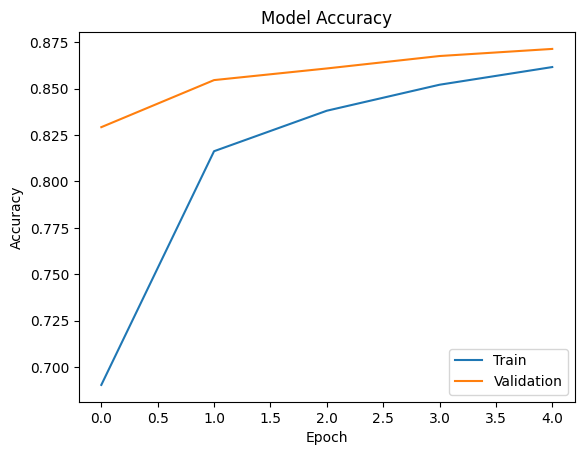

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()


In [35]:
!git remote add origin https://AMA2008-123@github.com/AMA2008-123/CODEALPHA_Handwritten-character-recognition-.git


fatal: not a git repository (or any of the parent directories): .git
